# Importing Required Libraries

Before starting the analysis, the necessary Python libraries are imported.

These libraries are used for:

- **Pandas** and **NumPy** for data loading, manipulation, and numerical operations.
- **Matplotlib** for data visualization.
- **Scikit-learn** modules for data preprocessing, splitting the dataset, building machine learning models, and evaluating their performance.

These libraries provide the tools needed to complete both the regression and clustering tasks in this project.

In [42]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt

# Import preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import regression model
from sklearn.linear_model import LinearRegression

# Import evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Import clustering algorithm
from sklearn.cluster import KMeans

# Loading the Dataset

In this step, the California Housing dataset is loaded into a pandas DataFrame directly from the ZIP file.

After loading the data, the first five rows are displayed to provide an initial overview of the dataset. The dimensions of the dataset are also shown to determine the total number of rows and columns, helping us understand the size of the data before performing further analysis.

In [43]:
# Load the dataset directly from the ZIP file
df = pd.read_csv("archive (2).zip", compression="zip")

# Display the first five rows
print("First Five Rows:")
display(df.head())

# Display the dataset dimensions
print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

First Five Rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Dataset Shape: 20640 rows, 10 columns


# Exploring the Dataset

Before building any machine learning model, it is important to understand the structure and quality of the dataset.

In this step, the dataset is explored by:
- Displaying general information such as the number of entries, data types, and non-null values.
- Generating summary statistics for the numerical features, including the mean, minimum, maximum, and quartiles.
- Checking for missing values that may need to be handled during preprocessing.
- Identifying duplicate rows to ensure the dataset does not contain redundant records.

These checks help verify that the dataset is clean and ready for the preprocessing stage.

In [44]:
# ============================================================
# Explore the Dataset
# ============================================================

# Display dataset information
print("Dataset Information:")
df.info()

# Display summary statistics
print("\nSummary Statistics:")
display(df.describe())

# Check for missing values
print("\nMissing Values:")
display(df.isnull().sum())

# Check duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB

Summary Statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



Missing Values:


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Duplicate Rows: 0


# Data Preprocessing

Before training the machine learning models, the dataset is preprocessed to ensure it is clean and suitable for analysis.

In this step:
- Missing values in the **total_bedrooms** column are replaced with the median value to avoid losing data while minimizing the effect of outliers.
- The categorical feature **ocean_proximity** is converted into numerical variables using one-hot encoding, allowing it to be used by machine learning algorithms such as Linear Regression.
- The dataset is then reviewed to verify that the preprocessing steps have been successfully applied.

> **Note:** The one-hot encoding of the `ocean_proximity` feature was successfully completed during preprocessing. Since the notebook cell was executed more than once, the encoded columns already exist in the DataFrame, so the encoding step is not shown again to avoid creating duplicate columns.

In [45]:
# Fill missing values in the total_bedrooms column
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

# Verify missing values
df.isnull().sum()


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

# Feature Selection

Before training the regression model, the dataset is divided into **input features** and the **target variable**.

- The **input features (`X`)** include all the independent variables that will be used to predict house prices.
- The **target variable (`y`)** is **`median_house_value`**, which represents the median value of houses and is the variable the model aims to predict.

Finally, the shapes of the feature matrix and target vector are displayed to verify that the data has been prepared correctly for the next step.

In [46]:
# ============================================================
# Define Features and Target Variable
# ============================================================

# Input features
X = df.drop("median_house_value", axis=1)

# Target variable
y = df["median_house_value"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 9)
Target Shape: (20640,)


# Splitting and Scaling the Data

To evaluate the performance of the regression model, the dataset is divided into two subsets:

- **Training set (80%)**: Used to train the Linear Regression model.
- **Testing set (20%)**: Used to evaluate the model on unseen data.

A fixed **random state** is used to ensure that the data split is reproducible.

After splitting the data, **feature scaling** is performed using **StandardScaler**. Standardization transforms the numerical features so that they have a mean of 0 and a standard deviation of 1. This helps ensure that features with different scales contribute equally during model training and improves the overall performance and stability of the machine learning algorithm.

In [47]:
### Prepare Features for Modeling The feature set `X` is prepared by ensuring all input variables are in a numerical format suitable for machine learning models.  
##The dataset is then split into training and testing sets, followed by feature standardization.
X = pd.get_dummies(X, drop_first=True)

# ============================================================
# Split the Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

# ============================================================
# Standardize the Features
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training Features: (16512, 12)
Testing Features : (4128, 12)


# Training the Linear Regression Model

After preparing the data, a **Linear Regression** model is created and trained using the standardized training dataset.

Once the training process is complete, the model learns the relationship between the input features and the target variable (**median_house_value**).

The trained model is then used to predict house prices for the testing dataset. These predictions will later be compared with the actual house prices to evaluate the model's performance using appropriate regression metrics.

In [48]:
# ============================================================
# Train Linear Regression Model
# ============================================================

model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Model training completed successfully.")

# ============================================================
# Predict House Prices
# ============================================================

y_pred = model.predict(X_test_scaled)
print("First 10 Predictions:")
print(y_pred[:10])

Model training completed successfully.
First 10 Predictions:
[ 54055.44889898 124225.33893718 255489.37949166 268002.43156919
 262769.43481568 139606.3039556  290665.42391417 228264.87637529
 256506.78561005 407923.85843486]


# Model Evaluation

After generating predictions, the performance of the Linear Regression model is evaluated using two common regression metrics:

- **Root Mean Squared Error (RMSE):** Measures the average difference between the predicted and actual house prices. A lower RMSE indicates that the model's predictions are closer to the true values.
- **R² Score (Coefficient of Determination):** Measures how well the model explains the variability in the target variable. An R² value closer to **1** indicates better predictive performance.

In addition, a comparison between the **actual** and **predicted** house prices is displayed to provide a clear view of the model's prediction accuracy.

In [49]:
# ============================================================
# Evaluate the Regression Model
# ============================================================

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# ============================================================
# Compare Actual and Predicted Values
# ============================================================

comparison = pd.DataFrame({"Actual": y_test.values,"Predicted": y_pred})
comparison.head(10)

Root Mean Squared Error (RMSE): 70060.52
R² Score: 0.6254


,Actual,Predicted
0,47700.0,54055.448899
1,45800.0,124225.338937
2,500001.0,255489.379492
3,218600.0,268002.431569
4,278000.0,262769.434816
5,158700.0,139606.303956
6,198200.0,290665.423914
7,157500.0,228264.876375
8,340000.0,256506.785610
9,446600.0,407923.858435


# Selecting Features for Clustering

For the clustering task, a subset of numerical features is selected from the dataset to group similar housing districts.

The selected features are:

- **Median Income:** Represents the median income of households in each district.
- **Housing Median Age:** Indicates the median age of houses within the district.
- **Total Rooms:** Represents the total number of rooms in the district.

These features were chosen because they provide meaningful information about the characteristics of each housing district and are suitable for applying the K-Means clustering algorithm. Using only numerical features is essential since K-Means calculates the distance between data points to form clusters.

In [50]:
# ============================================================
# Select Features for Clustering
# ============================================================

clustering_features = df[["median_income", "housing_median_age", "total_rooms"]]
clustering_features.head()

,median_income,housing_median_age,total_rooms
0,8.3252,41.0,880.0
1,8.3014,21.0,7099.0
2,7.2574,52.0,1467.0
3,5.6431,52.0,1274.0
4,3.8462,52.0,1627.0


# Standardizing the Clustering Features

Before applying the K-Means algorithm, the selected features are standardized using **StandardScaler**.

Standardization transforms each feature so that it has a mean of **0** and a standard deviation of **1**. This is an important preprocessing step because the selected features have different scales and units.

Since K-Means groups data points based on the Euclidean distance between them, standardizing the features ensures that no single feature has a greater influence on the clustering process simply because of its larger numerical values.

In [51]:
# ============================================================
# Standardize Clustering Features
# ============================================================

scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_features)

# Determining the Optimal Number of Clusters

Before training the K-Means model, it is important to determine the most appropriate number of clusters (**K**).

The **Elbow Method** is used for this purpose. It calculates the **Within-Cluster Sum of Squares (WCSS)** for different values of **K**. WCSS measures how closely the data points are grouped around their cluster centers. Lower WCSS values indicate more compact clusters.

The K-Means algorithm is trained multiple times using values of **K** ranging from **1 to 10**, and the corresponding WCSS values are recorded. These values will be used to create the elbow plot, which helps identify the point where increasing the number of clusters provides only a small improvement. This point is considered the optimal number of clusters.

In [52]:
# ============================================================
# Elbow Method
# ============================================================

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

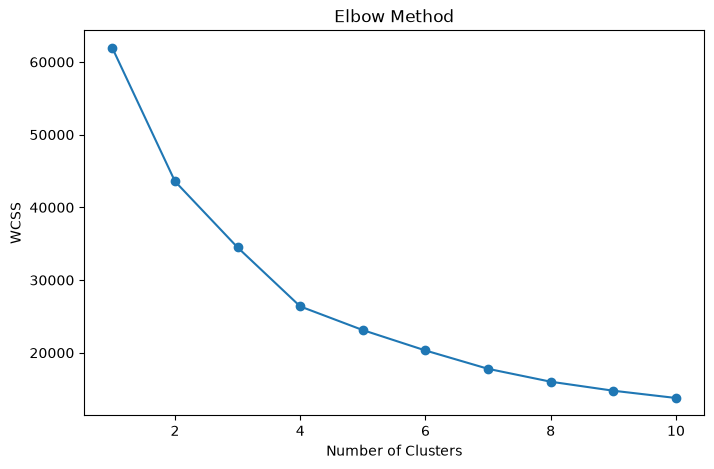

In [53]:
# ============================================================
# Plot Elbow Curve
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## Train K-Means Clustering Model

Based on the **Elbow Method**, 4 clusters were selected as the optimal number of clusters.

In [54]:
# ============================================================
# Train the K-Means Model
# ============================================================

kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
clusters = kmeans.fit_predict(scaled_features)
df["Cluster"] = clusters
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,Cluster
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,2
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,2


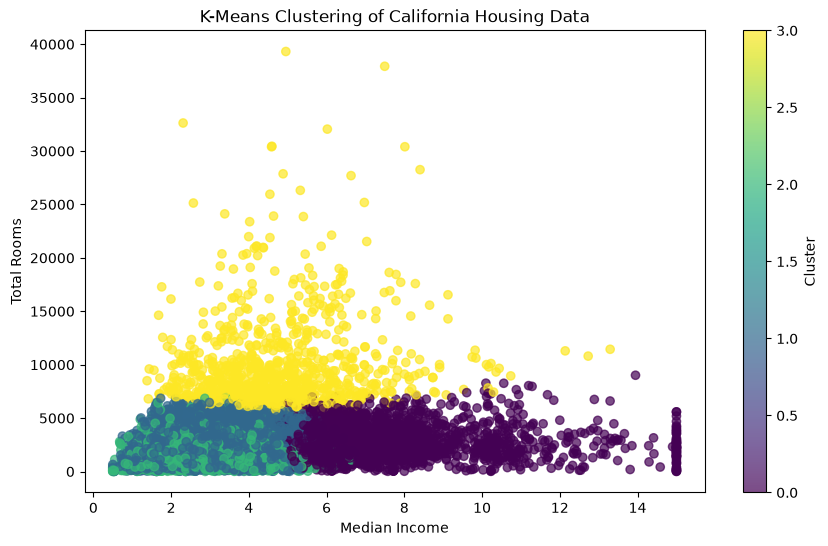

In [55]:
# ============================================================
# Visualize the Clusters
# ============================================================

plt.figure(figsize=(10, 6))
plt.scatter(df["median_income"],df["total_rooms"],c=df["Cluster"],cmap="viridis",alpha=0.7)
plt.title("K-Means Clustering of California Housing Data")
plt.xlabel("Median Income")
plt.ylabel("Total Rooms")
plt.colorbar(label="Cluster")
plt.show()

# Conclusion

In this project, I applied both **supervised** and **unsupervised** machine learning techniques using the California Housing dataset.

## Data Preprocessing

Before building the models, the dataset was explored and prepared for analysis. Missing values were handled by replacing them with the median value, duplicate records were checked, and the categorical feature (`ocean_proximity`) was converted into numerical variables using one-hot encoding so it could be used by the regression model.

## Regression

For the supervised learning task, a **Linear Regression** model was trained to predict the **median house value** based on the available housing features.

The dataset was divided into training and testing sets to evaluate the model on unseen data. Feature scaling was applied before training the model, and predictions were generated for the test set.

The model was evaluated using two metrics:

- **Root Mean Squared Error (RMSE):** Measures the average prediction error. Lower values indicate better prediction accuracy.
- **R² Score:** Measures how well the model explains the variation in house prices. A value closer to 1 indicates better performance.

These evaluation metrics provided a clear understanding of how well the regression model performed.

## Clustering

For the unsupervised learning task, the **K-Means** clustering algorithm was used to group similar housing districts based on selected numerical features.

The selected features were standardized before clustering because K-Means is distance-based and performs better when all features are on the same scale.

The **Elbow Method** was used to determine the optimal number of clusters. Based on the elbow plot, **4 clusters** were selected because the decrease in WCSS became much smaller after this point, indicating that adding more clusters would provide only a limited improvement.

Finally, the clusters were visualized using a scatter plot, making it easier to observe how the housing districts were grouped according to their characteristics.

## Overall

This project provided practical experience in:

- Data exploration and preprocessing.
- Building and evaluating a Linear Regression model.
- Applying feature scaling.
- Using the K-Means clustering algorithm.
- Selecting the optimal number of clusters using the Elbow Method.
- Visualizing machine learning results.

Overall, the project demonstrated the complete workflow of a machine learning task, starting from data preparation and ending with model evaluation and interpretation of the results.